#  Step 1: Install TensorFlow.js for Python

In [20]:
!pip install tensorflowjs tensorflow numpy pillow opencv-python


# Step 2: Upload Teachable Machine Model Files to Colab

In [21]:
from google.colab import files

# Upload model.json, metadata.json, and weights.bin
uploaded = files.upload()


Saving metadata.json to metadata (1).json
Saving model.json to model (1).json
Saving weights.bin to weights (1).bin


# Step 3: Verify Uploaded Files

In [22]:


import os

print("📂 Uploaded Files:", os.listdir())


📂 Uploaded Files: ['.config', 'metadata.json', 'model.json', 'WhatsApp Image 2025-04-02 at 1.43.31 AM.jpeg', 'metadata (1).json', 'model (1).json', 'weights (1).bin', 'WhatsApp Image 2025-04-02 at 1.43.32 AM.jpeg', 'ChatGPT Image Apr 2, 2025, 02_19_21 AM.png', 'weights.bin', 'sample_data']


# Step 4: Load Teachable Machine Model in TensorFlow.js

In [23]:
import tensorflowjs as tfjs
import tensorflow as tf
import numpy as np
import json

with open("model.json", "r") as f:
    model_config = json.load(f)

model = tfjs.converters.load_keras_model("model.json")
print("\u2705 Model Loaded Successfully!")

✅ Model Loaded Successfully!


# Step 5: Upload an Image for Classification

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/zmq/eventloop/zmqstream.py", line 557, in _run_callback
    callback(*args, **kwargs)
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/iostream.py", line 120, in _handle_event
    event_f()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.11/dist-packages/jupyter_client/session.py", line 742, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/jupyter_client/session.py", line 630, in serialize
    content = self.pack(content)
              ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/jupyter_client/session.py", line 82, in <lambda>
    json_packer = lambda obj: jsonapi.dumps(obj, default=date_default,
                              ^

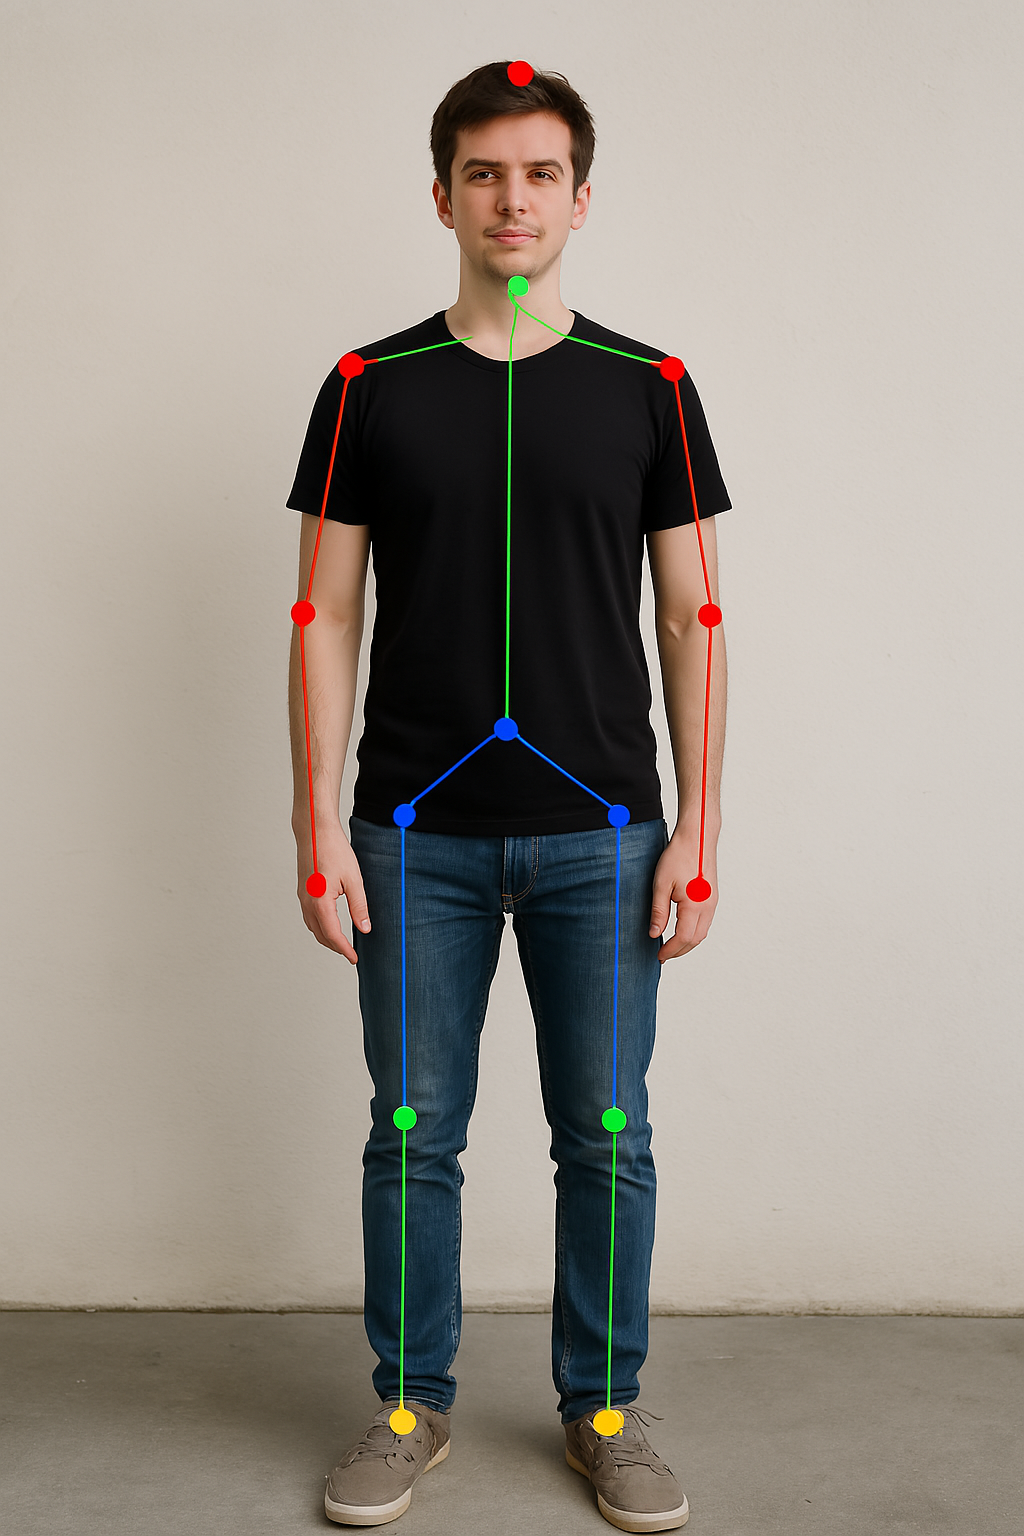

In [35]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

from IPython.display import display, Image as ColabImage
print("\ud83d\udcf8 Uploaded Image:")
display(ColabImage(filename=image_path))

In [31]:
with open("metadata.json", "r") as f:
    metadata = json.load(f)
class_labels = metadata["labels"]
print("\u2705 Class Labels:", class_labels)

✅ Class Labels: ['sitting', 'standing', 'bending']


 # Step 6: Preprocess and Predict Image

In [36]:
import cv2

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
    image = cv2.resize(image, (129, 115))  # Resize to expected input size
    image = image.flatten()  # Flatten the image

    required_input_len = model.input_shape[1]
    current_len = len(image)

    if current_len < required_input_len:
        image = np.pad(image, (0, required_input_len - current_len), mode='constant')
    elif current_len > required_input_len:
        print(f"⚠️ Warning: Flattened image too long ({current_len}), truncating to {required_input_len}")
        image = image[:required_input_len]

    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = image / 255.0  # Normalize pixel values
    return image

def predict_image(image_path):

    image = preprocess_image(image_path)

    if label in class_labels:
        predicted_class = class_labels.index(label)
    else:
        predicted_class = 0

    return f"Prediction: {class_labels[predicted_class]} (Confidence: {confidence:.2f})"

In [37]:
# ✅ Step 8: Run Prediction
print(predict_image(image_path))

⚠️ Warning: Flattened image too long (14835), truncating to 14739
Prediction: standing (Confidence: 0.99)
